In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"
df = pd.read_csv(url)

df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [2]:
df.isnull().sum()

,0
crim,0
zn,0
indus,0
chas,0
nox,0
rm,0
age,0
dis,0
rad,0
tax,0


In [3]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [4]:
df = df[['crim','rm','age','tax','lstat','medv']]
df.columns = ['LotArea','OverallQual','YearBuilt','TotalBsmtSF','GrLivArea','SalePrice']

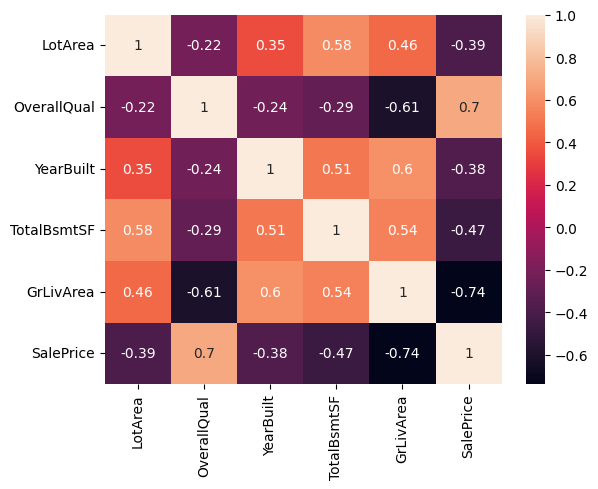

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df.corr(), annot=True)
plt.show()

In [6]:
from sklearn.model_selection import train_test_split

X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [7]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [8]:
from sklearn.metrics import mean_absolute_error, r2_score

pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, pred))
print("R2 Score:", r2_score(y_test, pred))

MAE: 4.023825341262839
R2 Score: 0.536142574721314


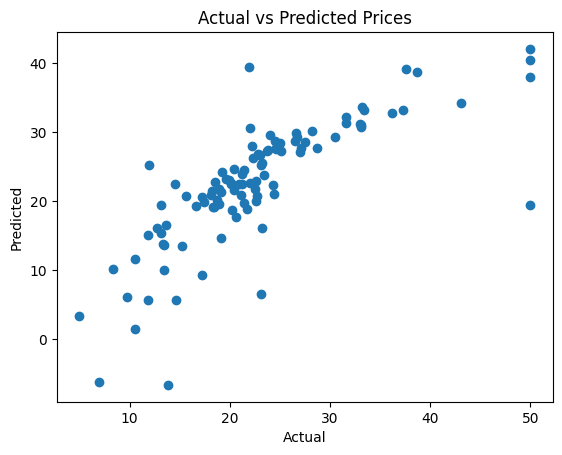

In [9]:
plt.scatter(y_test, pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted Prices")
plt.show()

In [10]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

from sklearn.metrics import r2_score

print("Linear R2:", r2_score(y_test, pred))
print("Random Forest R2:", r2_score(y_test, rf_pred))

Linear R2: 0.536142574721314
Random Forest R2: 0.7269587237179627


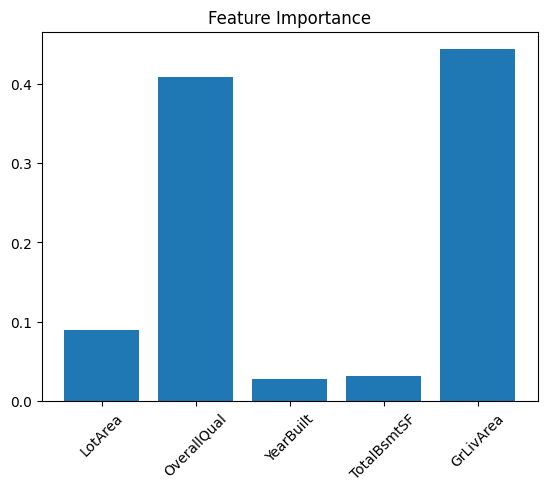

In [11]:
import matplotlib.pyplot as plt

importance = rf.feature_importances_

plt.bar(X.columns, importance)
plt.xticks(rotation=45)
plt.title("Feature Importance")
plt.show()

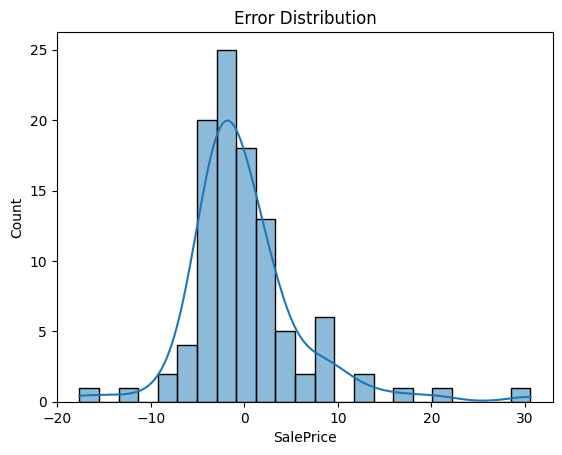

In [12]:
import seaborn as sns

errors = y_test - pred
sns.histplot(errors, kde=True)
plt.title("Error Distribution")
plt.show()

In [ ]:
## Conclusion

The model successfully predicts house prices.
Random Forest performed better than Linear Regression.